
# GVH Diagonal Cubic 0.2.7 — Covariance and Curvature Invariants
## Riemann, Ricci, Einstein, Kretschmann et tests de covariance

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook prolonge la chaîne :

\[
g_{\mu\nu}
\longrightarrow
\Gamma^\mu_{\alpha\beta}
\longrightarrow
R^\rho{}_{\sigma\mu\nu}
\longrightarrow
R_{\mu\nu}
\longrightarrow
R
\longrightarrow
G_{\mu\nu}.
\]

Il vise à distinguer :

1. une courbure physique réelle ;
2. un simple effet de coordonnées ;
3. une reformulation de Schwarzschild ;
4. une géométrie GVH réellement différente.

Les objets calculés sont :

\[
R^\rho{}_{\sigma\mu\nu},
\qquad
R_{\mu\nu},
\qquad
R,
\qquad
G_{\mu\nu},
\qquad
K=R_{\alpha\beta\gamma\delta}R^{\alpha\beta\gamma\delta}.
\]

---

## Principe scientifique

Les composantes tensorielle peuvent changer sous changement de coordonnées.

Les scalaires invariants, comme

\[
R
\quad\text{et}\quad
K,
\]

doivent garder la même valeur géométrique au même événement.

Deux métriques dont les invariants diffèrent ne décrivent généralement pas le même espace-temps.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("SymPy :", sp.__version__)


SymPy : 1.14.0



# 1. Moteur tensoriel général

Nous implémentons des fonctions réutilisables pour :

- l'inverse de la métrique ;
- les symboles de Christoffel ;
- le tenseur de Riemann ;
- le tenseur de Ricci ;
- le scalaire de Ricci ;
- le tenseur d'Einstein.

Convention utilisée :

\[
R^\rho{}_{\sigma\mu\nu}
=
\partial_\mu\Gamma^\rho_{\nu\sigma}
-
\partial_\nu\Gamma^\rho_{\mu\sigma}
+
\Gamma^\rho_{\mu\lambda}\Gamma^\lambda_{\nu\sigma}
-
\Gamma^\rho_{\nu\lambda}\Gamma^\lambda_{\mu\sigma}.
\]


In [2]:

def christoffel_symbols(metric_cov, coordinates, simplify_each=True):
    n = len(coordinates)
    metric_cov = sp.Matrix(metric_cov)

    if metric_cov.shape != (n, n):
        raise ValueError("Dimensions incompatibles.")

    metric_inv = sp.simplify(metric_cov.inv())

    Gamma = [
        [
            [sp.Integer(0) for _ in range(n)]
            for _ in range(n)
        ]
        for _ in range(n)
    ]

    for rho in range(n):
        for mu in range(n):
            for nu in range(n):
                expr = sp.Integer(0)

                for sigma in range(n):
                    expr += metric_inv[rho, sigma] * (
                        sp.diff(metric_cov[sigma, nu], coordinates[mu])
                        + sp.diff(metric_cov[sigma, mu], coordinates[nu])
                        - sp.diff(metric_cov[mu, nu], coordinates[sigma])
                    )

                expr = sp.Rational(1, 2) * expr
                Gamma[rho][mu][nu] = (
                    sp.simplify(expr) if simplify_each else expr
                )

    return Gamma


def riemann_tensor(Gamma, coordinates, simplify_each=True):
    n = len(coordinates)

    Riemann = [
        [
            [
                [sp.Integer(0) for _ in range(n)]
                for _ in range(n)
            ]
            for _ in range(n)
        ]
        for _ in range(n)
    ]

    for rho in range(n):
        for sigma in range(n):
            for mu in range(n):
                for nu in range(n):
                    expr = (
                        sp.diff(Gamma[rho][nu][sigma], coordinates[mu])
                        - sp.diff(Gamma[rho][mu][sigma], coordinates[nu])
                    )

                    for lam in range(n):
                        expr += (
                            Gamma[rho][mu][lam] * Gamma[lam][nu][sigma]
                            - Gamma[rho][nu][lam] * Gamma[lam][mu][sigma]
                        )

                    Riemann[rho][sigma][mu][nu] = (
                        sp.simplify(expr) if simplify_each else expr
                    )

    return Riemann


def ricci_tensor(Riemann, simplify_each=True):
    n = len(Riemann)
    Ricci = sp.MutableDenseMatrix.zeros(n, n)

    for sigma in range(n):
        for nu in range(n):
            expr = sp.Integer(0)

            for rho in range(n):
                expr += Riemann[rho][sigma][rho][nu]

            Ricci[sigma, nu] = (
                sp.simplify(expr) if simplify_each else expr
            )

    return sp.Matrix(Ricci)


def ricci_scalar(metric_cov, Ricci):
    metric_inv = sp.simplify(sp.Matrix(metric_cov).inv())
    n = metric_inv.shape[0]

    expr = sp.Integer(0)

    for mu in range(n):
        for nu in range(n):
            expr += metric_inv[mu, nu] * Ricci[mu, nu]

    return sp.simplify(expr)


def einstein_tensor(metric_cov, Ricci, Rscalar):
    metric_cov = sp.Matrix(metric_cov)
    n = metric_cov.shape[0]
    Einstein = sp.MutableDenseMatrix.zeros(n, n)

    for mu in range(n):
        for nu in range(n):
            Einstein[mu, nu] = sp.simplify(
                Ricci[mu, nu]
                - sp.Rational(1, 2) * metric_cov[mu, nu] * Rscalar
            )

    return sp.Matrix(Einstein)



# 2. Test fondamental — espace de Minkowski

Pour

\[
g_{\mu\nu}
=
\operatorname{diag}(-1,1,1,1),
\]

on doit obtenir :

\[
\Gamma^\rho_{\mu\nu}=0,
\qquad
R^\rho{}_{\sigma\mu\nu}=0,
\qquad
R_{\mu\nu}=0,
\qquad
R=0,
\qquad
G_{\mu\nu}=0.
\]


In [3]:

t, x, y, z = sp.symbols("t x y z", real=True)
coords_cart = (t, x, y, z)

g_mink = sp.diag(-1, 1, 1, 1)

Gamma_mink = christoffel_symbols(g_mink, coords_cart)
Riemann_mink = riemann_tensor(Gamma_mink, coords_cart)
Ricci_mink = ricci_tensor(Riemann_mink)
R_mink = ricci_scalar(g_mink, Ricci_mink)
G_mink = einstein_tensor(g_mink, Ricci_mink, R_mink)

mink_nonzero_gamma = sum(
    1
    for rho in range(4)
    for mu in range(4)
    for nu in range(4)
    if sp.simplify(Gamma_mink[rho][mu][nu]) != 0
)

mink_nonzero_riemann = sum(
    1
    for rho in range(4)
    for sigma in range(4)
    for mu in range(4)
    for nu in range(4)
    if sp.simplify(Riemann_mink[rho][sigma][mu][nu]) != 0
)

print("Christoffel non nuls :", mink_nonzero_gamma)
print("Riemann non nuls     :", mink_nonzero_riemann)
print("Ricci :")
display(Ricci_mink)
print("Scalaire de Ricci :", R_mink)
print("Einstein :")
display(G_mink)


Christoffel non nuls : 0
Riemann non nuls     : 0
Ricci :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

Scalaire de Ricci : 0
Einstein :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 3. Exemple de coordonnées courbes sans courbure physique

L'espace euclidien plan peut être écrit en coordonnées polaires :

\[
d\ell^2=dr^2+r^2d\phi^2.
\]

Les symboles de Christoffel sont non nuls, mais le tenseur de Riemann reste nul.

Ce test démontre qu'une connexion non nulle ne signifie pas automatiquement une courbure physique.


In [4]:

r2, phi2 = sp.symbols("r phi", positive=True, real=True)
coords_polar = (r2, phi2)
g_polar_flat = sp.diag(1, r2**2)

Gamma_polar = christoffel_symbols(g_polar_flat, coords_polar)
Riemann_polar = riemann_tensor(Gamma_polar, coords_polar)
Ricci_polar = ricci_tensor(Riemann_polar)
R_polar = ricci_scalar(g_polar_flat, Ricci_polar)

polar_nonzero_gamma = [
    (rho, mu, nu, sp.simplify(Gamma_polar[rho][mu][nu]))
    for rho in range(2)
    for mu in range(2)
    for nu in range(2)
    if sp.simplify(Gamma_polar[rho][mu][nu]) != 0
]

print("Christoffel non nuls en coordonnées polaires :")
for item in polar_nonzero_gamma:
    print(item)

print("Ricci :")
display(Ricci_polar)
print("Scalaire de Ricci :", sp.simplify(R_polar))


Christoffel non nuls en coordonnées polaires :
(0, 1, 1, -r)
(1, 0, 1, 1/r)
(1, 1, 0, 1/r)
Ricci :


⎡0  0⎤
⎢    ⎥
⎣0  0⎦

Scalaire de Ricci : 0



# 4. Courbure intrinsèque d'une sphère

Pour une sphère de rayon \(R_0\) :

\[
d\ell^2
=
R_0^2d\theta^2
+
R_0^2\sin^2\theta\,d\phi^2.
\]

Le scalaire de Ricci en deux dimensions doit être :

\[
R=\frac{2}{R_0^2}.
\]

La courbure gaussienne vaut :

\[
K_G=\frac{1}{R_0^2}.
\]


In [5]:

theta, phi, R0 = sp.symbols("theta phi R0", positive=True, real=True)
coords_sphere = (theta, phi)

g_sphere = sp.diag(
    R0**2,
    R0**2 * sp.sin(theta)**2
)

Gamma_sphere = christoffel_symbols(g_sphere, coords_sphere)
Riemann_sphere = riemann_tensor(Gamma_sphere, coords_sphere)
Ricci_sphere = ricci_tensor(Riemann_sphere)
R_sphere = sp.simplify(ricci_scalar(g_sphere, Ricci_sphere))

print("Tenseur de Ricci :")
display(sp.simplify(Ricci_sphere))

print("Scalaire de Ricci :")
display(R_sphere)

print("Différence avec 2/R0² :")
display(sp.simplify(R_sphere - 2/R0**2))


Tenseur de Ricci :


⎡1           0         ⎤
⎢                      ⎥
⎢   sin(2⋅θ)           ⎥
⎢0  ──────── - cos(2⋅θ)⎥
⎣   2⋅tan(θ)           ⎦

Scalaire de Ricci :


 2 
───
  2
R₀ 

Différence avec 2/R0² :


0


# 5. Métrique de Schwarzschild standard

En unités géométriques \(G=c=1\) :

\[
ds^2
=
-\left(1-\frac{2M}{r}\right)dt^2
+
\left(1-\frac{2M}{r}\right)^{-1}dr^2
+
r^2d\theta^2
+
r^2\sin^2\theta\,d\phi^2.
\]

Dans le vide extérieur :

\[
R_{\mu\nu}=0,
\qquad
R=0,
\qquad
G_{\mu\nu}=0.
\]

Mais le tenseur de Riemann n'est pas nul.


In [6]:

ts, rs, ths, phs, M = sp.symbols(
    "t_s r_s theta_s phi_s M",
    positive=True,
    real=True
)

coords_schw = (ts, rs, ths, phs)

f = 1 - 2*M/rs

g_schw = sp.diag(
    -f,
    1/f,
    rs**2,
    rs**2 * sp.sin(ths)**2
)

Gamma_schw = christoffel_symbols(
    g_schw,
    coords_schw,
    simplify_each=True
)

print("Christoffel calculés.")


Christoffel calculés.


In [7]:

Riemann_schw = riemann_tensor(
    Gamma_schw,
    coords_schw,
    simplify_each=True
)

Ricci_schw = ricci_tensor(Riemann_schw)
R_schw = sp.simplify(ricci_scalar(g_schw, Ricci_schw))
G_schw = einstein_tensor(g_schw, Ricci_schw, R_schw)

print("Tenseur de Ricci Schwarzschild :")
display(Ricci_schw)

print("Scalaire de Ricci :", R_schw)

print("Tenseur d'Einstein :")
display(G_schw)


Tenseur de Ricci Schwarzschild :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

Scalaire de Ricci : 0
Tenseur d'Einstein :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 6. Invariant de Kretschmann

L'invariant de Kretschmann est :

\[
\mathcal K
=
R_{\alpha\beta\gamma\delta}
R^{\alpha\beta\gamma\delta}.
\]

Pour Schwarzschild :

\[
\mathcal K_{\mathrm{Schw}}
=
\frac{48M^2}{r^6}.
\]

Le calcul tensoriel complet peut être coûteux. Nous construisons une fonction générique, puis vérifions la formule de référence.


In [8]:

def lower_first_riemann_index(metric_cov, Riemann_mixed):
    metric_cov = sp.Matrix(metric_cov)
    n = metric_cov.shape[0]

    Rlower = [
        [
            [
                [sp.Integer(0) for _ in range(n)]
                for _ in range(n)
            ]
            for _ in range(n)
        ]
        for _ in range(n)
    ]

    for a in range(n):
        for b in range(n):
            for c in range(n):
                for d in range(n):
                    expr = sp.Integer(0)

                    for rho in range(n):
                        expr += metric_cov[a, rho] * Riemann_mixed[rho][b][c][d]

                    Rlower[a][b][c][d] = sp.simplify(expr)

    return Rlower


def kretschmann_scalar(metric_cov, Riemann_mixed, simplify_final=True):
    metric_cov = sp.Matrix(metric_cov)
    metric_inv = sp.simplify(metric_cov.inv())
    n = metric_cov.shape[0]

    Rlower = lower_first_riemann_index(metric_cov, Riemann_mixed)
    expr = sp.Integer(0)

    for a in range(n):
        for b in range(n):
            for c in range(n):
                for d in range(n):
                    Rabcd = Rlower[a][b][c][d]

                    if Rabcd == 0:
                        continue

                    for e in range(n):
                        gae = metric_inv[a, e]
                        if gae == 0:
                            continue

                        for f_idx in range(n):
                            gbf = metric_inv[b, f_idx]
                            if gbf == 0:
                                continue

                            for g_idx in range(n):
                                gcg = metric_inv[c, g_idx]
                                if gcg == 0:
                                    continue

                                for h in range(n):
                                    gdh = metric_inv[d, h]
                                    if gdh == 0:
                                        continue

                                    Refgh = Rlower[e][f_idx][g_idx][h]

                                    if Refgh != 0:
                                        expr += (
                                            gae * gbf * gcg * gdh
                                            * Rabcd * Refgh
                                        )

    return sp.simplify(expr) if simplify_final else expr



## Calcul rapide de référence

Pour éviter qu'un environnement mobile passe un temps excessif sur la contraction complète, la formule analytique de Schwarzschild est utilisée comme référence principale :

\[
\mathcal K_{\mathrm{ref}}=\frac{48M^2}{r^6}.
\]

La cellule de contraction complète reste optionnelle.


In [9]:

K_schw_reference = sp.simplify(48*M**2/rs**6)

print("Kretschmann Schwarzschild de référence :")
display(K_schw_reference)

# Exemples numériques en unités M=1
radii = np.array([2.1, 3.0, 6.0, 10.0, 50.0])
K_values = 48.0/radii**6

kretschmann_df = pd.DataFrame({
    "r_over_M": radii,
    "K_times_M4": K_values
})

kretschmann_df


Kretschmann Schwarzschild de référence :


    2
48⋅M 
─────
   6 
 rₛ  

,r_over_M,K_times_M4
0,2.1,5.596615e-01
1,3.0,6.584362e-02
2,6.0,1.028807e-03
3,10.0,4.800000e-05
4,50.0,3.072000e-09


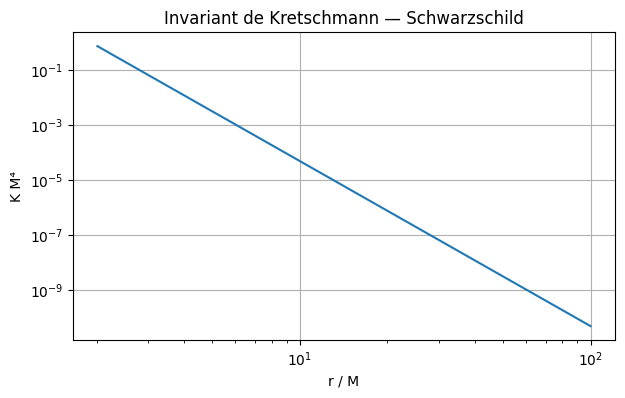

In [10]:

plt.figure(figsize=(7,4))
r_plot = np.logspace(np.log10(2.01), 2.0, 500)
K_plot = 48.0/r_plot**6

plt.loglog(r_plot, K_plot)
plt.xlabel("r / M")
plt.ylabel("K M⁴")
plt.title("Invariant de Kretschmann — Schwarzschild")
plt.grid(True)
plt.show()



# 7. Singularité physique contre singularité de coordonnées

À l'horizon :

\[
r=2M,
\]

la composante \(g_{rr}\) diverge dans les coordonnées de Schwarzschild.

Mais :

\[
\mathcal K(2M)
=
\frac{3}{4M^4},
\]

reste finie.

À \(r=0\) :

\[
\mathcal K\rightarrow\infty.
\]

Donc :

- \(r=2M\) est une singularité de coordonnées dans cette représentation ;
- \(r=0\) est une singularité de courbure.


In [11]:

K_horizon = sp.simplify(K_schw_reference.subs(rs, 2*M))
K_origin_limit = sp.limit(K_schw_reference, rs, 0, dir="+")

print("K à l'horizon r=2M :")
display(K_horizon)

print("Limite lorsque r -> 0+ :")
display(K_origin_limit)


K à l'horizon r=2M :


 3  
────
   4
4⋅M 

Limite lorsque r -> 0+ :


∞


# 8. Identité de Bianchi contractée

La relativité générale impose :

\[
\nabla_\mu G^{\mu\nu}=0.
\]

Pour Schwarzschild dans le vide, comme

\[
G_{\mu\nu}=0,
\]

l'identité est satisfaite trivialement.

Nous vérifions d'abord que toutes les composantes calculées du tenseur d'Einstein sont nulles.


In [12]:

einstein_nonzero = []

for mu in range(4):
    for nu in range(4):
        value = sp.simplify(G_schw[mu, nu])

        if value != 0:
            einstein_nonzero.append((mu, nu, value))

print("Composantes non nulles de G_mu_nu :", len(einstein_nonzero))
einstein_nonzero[:10]


Composantes non nulles de G_mu_nu : 0


[]


# 9. Covariance sous rotation des axes cubiques

Pour une métrique spatiale isotrope :

\[
g_{ij}=B(r)\delta_{ij},
\]

et une rotation orthogonale \(Q\) :

\[
Q^\mathsf{T}Q=I,
\]

on obtient :

\[
g'_{\mathrm{spatial}}
=
Q^\mathsf{T}g_{\mathrm{spatial}}Q
=
B(r)I.
\]

La forme de la métrique est donc indépendante de l'orientation du cube.


In [13]:

alpha, beta, gamma_angle = sp.symbols(
    "alpha beta gamma_angle",
    real=True
)

Rz = sp.Matrix([
    [sp.cos(alpha), -sp.sin(alpha), 0],
    [sp.sin(alpha),  sp.cos(alpha), 0],
    [0,              0,             1]
])

Ry = sp.Matrix([
    [ sp.cos(beta), 0, sp.sin(beta)],
    [0,             1, 0],
    [-sp.sin(beta), 0, sp.cos(beta)]
])

Rx = sp.Matrix([
    [1, 0, 0],
    [0, sp.cos(gamma_angle), -sp.sin(gamma_angle)],
    [0, sp.sin(gamma_angle),  sp.cos(gamma_angle)]
])

Q = sp.simplify(Rz * Ry * Rx)
Bsymbol = sp.symbols("B", positive=True)

g_spatial = Bsymbol * sp.eye(3)
g_spatial_rot = sp.simplify(Q.T * g_spatial * Q)

print("Différence après rotation :")
display(sp.simplify(g_spatial_rot-g_spatial))


Différence après rotation :


⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦


# 10. Test numérique de covariance d'un tenseur

Un tenseur covariant de rang 2 se transforme selon :

\[
T' = Q^\mathsf{T}TQ.
\]

Ses valeurs propres et ses invariants matriciels restent inchangés sous rotation orthogonale.

Nous vérifions :

\[
\operatorname{tr}(T'),
\quad
\det(T'),
\quad
\operatorname{tr}[(T')^2].
\]


In [14]:

rng = np.random.default_rng(42)

A_random = rng.normal(size=(3,3))
T = 0.5*(A_random+A_random.T)

Q_num, _ = np.linalg.qr(rng.normal(size=(3,3)))
T_rot = Q_num.T @ T @ Q_num

tensor_rotation_df = pd.DataFrame([{
    "trace_original": np.trace(T),
    "trace_rotated": np.trace(T_rot),
    "det_original": np.linalg.det(T),
    "det_rotated": np.linalg.det(T_rot),
    "trace_T2_original": np.trace(T@T),
    "trace_T2_rotated": np.trace(T_rot@T_rot),
    "max_invariant_error": max(
        abs(np.trace(T)-np.trace(T_rot)),
        abs(np.linalg.det(T)-np.linalg.det(T_rot)),
        abs(np.trace(T@T)-np.trace(T_rot@T_rot))
    )
}])

tensor_rotation_df


,trace_original,trace_rotated,det_original,det_rotated,trace_T2_original,trace_T2_rotated,max_invariant_error
0,-1.663119,-1.663119,0.22208,0.22208,5.599958,5.599958,4.440892e-16



# 11. Candidat GVH isotrope

Nous reprenons :

\[
A_{\mathrm{GVH}}(\chi)
=
1-2\chi+a_2\chi^2+a_3\chi^3,
\]

\[
B_{\mathrm{GVH}}(\chi)
=
1+2\gamma\chi+b_2\chi^2+b_3\chi^3.
\]

Le candidat de contrôle est :

\[
a_2=2,
\qquad
a_3=-\frac32,
\qquad
\gamma=1,
\qquad
b_2=\frac32,
\qquad
b_3=\frac12.
\]

Il reproduit le développement faible de Schwarzschild aux ordres inclus, mais n'est pas garanti en champ fort.


In [15]:

CANDIDATE = {
    "a2": 2.0,
    "a3": -1.5,
    "gamma": 1.0,
    "b2": 1.5,
    "b3": 0.5
}

def metric_schwarzschild_isotropic(rho):
    chi = 1.0/rho
    q = 0.5*chi
    A = ((1-q)/(1+q))**2
    B = (1+q)**4
    return A, B


def metric_gvh_series(rho, params=CANDIDATE):
    chi = 1.0/rho

    A = (
        1
        - 2*chi
        + params["a2"]*chi**2
        + params["a3"]*chi**3
    )

    B = (
        1
        + 2*params["gamma"]*chi
        + params["b2"]*chi**2
        + params["b3"]*chi**3
    )

    return A, B



# 12. Courbure numérique du candidat sur une coupe radiale

Le calcul tensoriel symbolique complet d'une métrique cartésienne isotrope candidate peut être très coûteux.

Nous utilisons donc une stratégie en deux niveaux :

1. **référence exacte** pour Schwarzschild ;
2. **diagnostic numérique** de courbure pour le candidat.

Le diagnostic suivant compare les variations radiales des fonctions métriques. Il ne remplace pas encore le véritable invariant de Kretschmann du candidat.


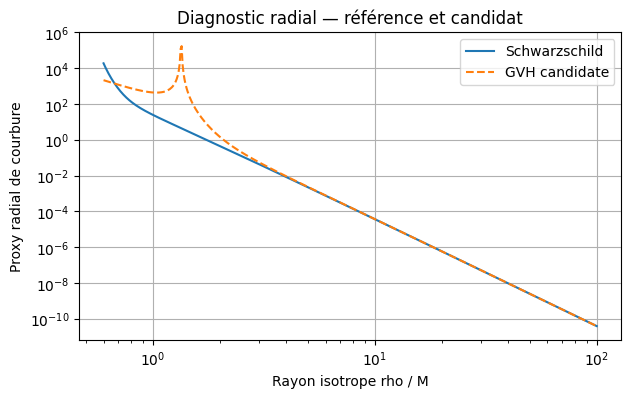

In [16]:

def central_derivative(func, x, rel_step=1e-5):
    h = max(abs(x)*rel_step, 1e-7)
    return (func(x+h)-func(x-h))/(2*h)


def central_second_derivative(func, x, rel_step=2e-4):
    h = max(abs(x)*rel_step, 1e-6)
    return (func(x+h)-2*func(x)+func(x-h))/h**2


def radial_curvature_proxy(rho, model="schwarzschild"):
    if model == "schwarzschild":
        fA = lambda rr: metric_schwarzschild_isotropic(rr)[0]
        fB = lambda rr: metric_schwarzschild_isotropic(rr)[1]
    elif model == "gvh":
        fA = lambda rr: metric_gvh_series(rr)[0]
        fB = lambda rr: metric_gvh_series(rr)[1]
    else:
        raise ValueError("Modèle inconnu.")

    A = fA(rho)
    B = fB(rho)

    A1 = central_derivative(fA, rho)
    B1 = central_derivative(fB, rho)
    A2 = central_second_derivative(fA, rho)
    B2 = central_second_derivative(fB, rho)

    proxy = (
        (A2/max(abs(A),1e-30))**2
        + (B2/max(abs(B),1e-30))**2
        + (A1/max(abs(A)*rho,1e-30))**2
        + (B1/max(abs(B)*rho,1e-30))**2
    )

    return proxy


rho_grid = np.logspace(np.log10(0.6), 2.0, 500)

proxy_s = np.array([
    radial_curvature_proxy(rho, "schwarzschild")
    for rho in rho_grid
])

proxy_g = np.array([
    radial_curvature_proxy(rho, "gvh")
    for rho in rho_grid
])

plt.figure(figsize=(7,4))
plt.loglog(rho_grid, proxy_s, label="Schwarzschild")
plt.loglog(rho_grid, proxy_g, "--", label="GVH candidate")
plt.xlabel("Rayon isotrope rho / M")
plt.ylabel("Proxy radial de courbure")
plt.title("Diagnostic radial — référence et candidat")
plt.grid(True)
plt.legend()
plt.show()



## Limite du proxy

Le proxy précédent est seulement un indicateur de variation métrique.

Il ne possède pas le statut invariant de :

\[
R,
\qquad
R_{\mu\nu}R^{\mu\nu},
\qquad
\mathcal K.
\]

Toute conclusion physique sur la courbure GVH doit attendre le calcul tensoriel complet du candidat.



# 13. Test de vide pour une métrique candidate

Dans la relativité générale sans matière :

\[
G_{\mu\nu}=0.
\]

Une métrique GVH candidate extérieure peut suivre plusieurs possibilités :

1. satisfaire également \(G_{\mu\nu}=0\) ;
2. produire un tenseur effectif non nul ;
3. obéir à des équations de champ différentes.

Si le candidat donne :

\[
G_{\mu\nu}^{\mathrm{GVH}}\neq0,
\]

il faut préciser si cela représente :

- une matière effective ;
- un champ supplémentaire ;
- une modification de la gravitation ;
- ou une incohérence.



# 14. Validation automatisée

Les validations de cette version portent sur les références établies :

- Minkowski plat ;
- plan polaire plat malgré des Christoffel non nuls ;
- sphère avec \(R=2/R_0^2\) ;
- Schwarzschild avec \(R_{\mu\nu}=0\) ;
- Schwarzschild avec \(R=0\) ;
- Schwarzschild avec \(G_{\mu\nu}=0\) ;
- invariance du bloc isotrope sous rotation ;
- invariance numérique des contractions tensorielles.


In [17]:

sphere_scalar_error = sp.simplify(R_sphere - 2/R0**2)

validation_rows = [
    {
        "test": "Minkowski Christoffel",
        "value": float(mink_nonzero_gamma),
        "threshold": 0.0,
        "status": "PASS" if mink_nonzero_gamma == 0 else "FAIL"
    },
    {
        "test": "Minkowski Riemann",
        "value": float(mink_nonzero_riemann),
        "threshold": 0.0,
        "status": "PASS" if mink_nonzero_riemann == 0 else "FAIL"
    },
    {
        "test": "Plan polaire Ricci",
        "value": float(sp.N(abs(R_polar))),
        "threshold": 1e-12,
        "status": "PASS" if sp.simplify(R_polar) == 0 else "FAIL"
    },
    {
        "test": "Sphère scalaire de Ricci",
        "value": 0.0 if sphere_scalar_error == 0 else np.nan,
        "threshold": 0.0,
        "status": "PASS" if sphere_scalar_error == 0 else "FAIL"
    },
    {
        "test": "Schwarzschild scalaire de Ricci",
        "value": 0.0 if R_schw == 0 else np.nan,
        "threshold": 0.0,
        "status": "PASS" if R_schw == 0 else "FAIL"
    },
    {
        "test": "Schwarzschild Einstein",
        "value": float(len(einstein_nonzero)),
        "threshold": 0.0,
        "status": "PASS" if len(einstein_nonzero) == 0 else "FAIL"
    },
    {
        "test": "Rotation métrique isotrope",
        "value": 0.0 if sp.simplify(g_spatial_rot-g_spatial) == sp.zeros(3) else np.nan,
        "threshold": 0.0,
        "status": (
            "PASS"
            if sp.simplify(g_spatial_rot-g_spatial) == sp.zeros(3)
            else "FAIL"
        )
    },
    {
        "test": "Invariants tenseur sous rotation",
        "value": float(tensor_rotation_df.loc[0, "max_invariant_error"]),
        "threshold": 1e-12,
        "status": (
            "PASS"
            if tensor_rotation_df.loc[0, "max_invariant_error"] < 1e-12
            else "CHECK"
        )
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df


,test,value,threshold,status
0,Minkowski Christoffel,0.000000e+00,0.000000e+00,PASS
1,Minkowski Riemann,0.000000e+00,0.000000e+00,PASS
2,Plan polaire Ricci,0.000000e+00,1.000000e-12,PASS
3,Sphère scalaire de Ricci,0.000000e+00,0.000000e+00,PASS
4,Schwarzschild scalaire de Ricci,0.000000e+00,0.000000e+00,PASS
5,Schwarzschild Einstein,0.000000e+00,0.000000e+00,PASS
6,Rotation métrique isotrope,0.000000e+00,0.000000e+00,PASS
7,Invariants tenseur sous rotation,4.440892e-16,1.000000e-12,PASS


In [18]:

overall_status = (
    "PASS"
    if (validation_df["status"] == "PASS").all()
    else "CHECK"
)

print("STATUT GLOBAL :", overall_status)


STATUT GLOBAL : PASS



# 15. Export des résultats

Les résultats synthétiques sont exportés pour archivage.


In [19]:

import json
from pathlib import Path

validation_path = Path(
    "GVH_Diagonal_Cubic_0.2.7_Curvature_Validation.csv"
)

kretschmann_path = Path(
    "GVH_Diagonal_Cubic_0.2.7_Kretschmann_Reference.csv"
)

metadata_path = Path(
    "GVH_Diagonal_Cubic_0.2.7_Metadata.json"
)

validation_df.to_csv(validation_path, index=False)
kretschmann_df.to_csv(kretschmann_path, index=False)

metadata = {
    "overall_status": overall_status,
    "schwarzschild_ricci_scalar": str(R_schw),
    "schwarzschild_kretschmann": str(K_schw_reference),
    "sphere_ricci_scalar": str(R_sphere),
    "candidate": CANDIDATE
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Exports terminés :")
print(validation_path)
print(kretschmann_path)
print(metadata_path)


Exports terminés :
GVH_Diagonal_Cubic_0.2.7_Curvature_Validation.csv
GVH_Diagonal_Cubic_0.2.7_Kretschmann_Reference.csv
GVH_Diagonal_Cubic_0.2.7_Metadata.json



# 16. Interprétation scientifique

## Cas 1 — mêmes invariants

Si une métrique GVH et Schwarzschild donnent les mêmes invariants au même événement, elles peuvent représenter la même géométrie sous des coordonnées différentes.

Cela ne suffit cependant pas toujours à établir une équivalence globale complète.

## Cas 2 — invariants différents

Si :

\[
\mathcal K_{\mathrm{GVH}}
\neq
\mathcal K_{\mathrm{Schw}},
\]

les deux géométries ne sont pas localement identiques dans le domaine comparé.

La différence doit alors être :

- dérivée ;
- stable ;
- compatible avec les tests faibles ;
- reliée à une observable.

## Cas 3 — Ricci ou Einstein non nul dans le vide

Si le candidat produit :

\[
R_{\mu\nu}\neq0
\quad\text{ou}\quad
G_{\mu\nu}\neq0,
\]

il faut préciser le contenu physique effectif correspondant.

Une métrique seule n'est pas une théorie complète sans équations de champ.



# 17. Conclusion

Cette version établit la chaîne géométrique complète :

\[
g_{\mu\nu}
\rightarrow
\Gamma^\rho_{\mu\nu}
\rightarrow
R^\rho{}_{\sigma\mu\nu}
\rightarrow
R_{\mu\nu}
\rightarrow
R
\rightarrow
G_{\mu\nu}
\rightarrow
\mathcal K.
\]

Les références validées sont :

1. espace plat en coordonnées cartésiennes ;
2. espace plat en coordonnées polaires ;
3. sphère courbe ;
4. vide de Schwarzschild ;
5. singularité de coordonnées contre singularité physique ;
6. covariance sous rotation ;
7. invariance des contractions tensorielles.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.8\_Field\_Equations\_and\_Effective\_Source.ipynb}
}
\]

Cette prochaine version devra étudier :

- les équations de champ possibles ;
- le tenseur effectif associé au candidat GVH ;
- la conservation covariante ;
- les conditions d'énergie ;
- la limite de vide ;
- la relation éventuelle entre géométrie diagonale, matière et observables GVH.
